# Szept czy krzyk?

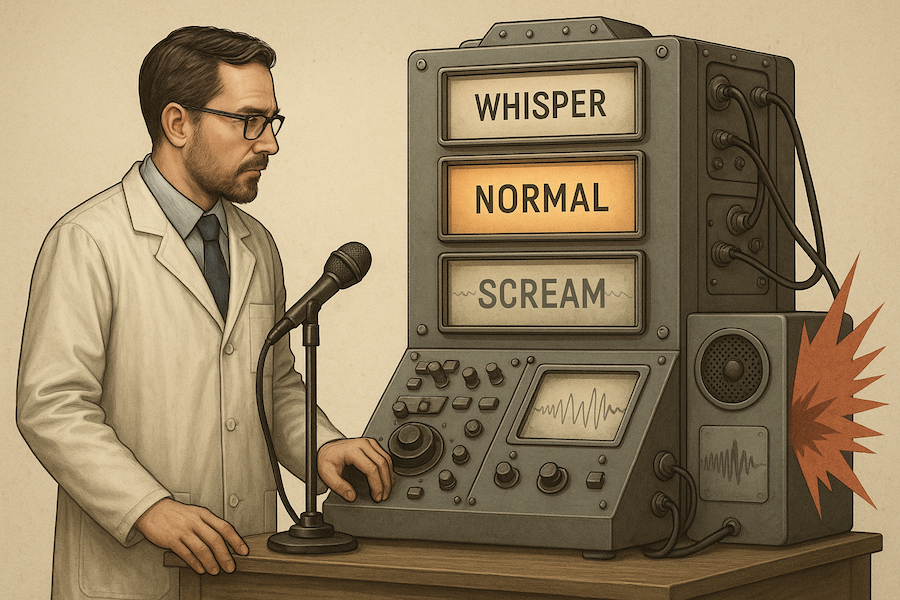


*Obraz wygenerowany przez narzędzie generowania obrazów ChatGPT.*

## Wstęp

W Instytucie Zaawansowanej Akustyki Eksperymentalnej panuje wyjątkowe poruszenie. Po wielu latach
uruchomiono prototyp **Maszyny do Oceniania Głośności Mowy**, czyli zaawansowanego urządzenia, które
potrafi ocenić głośność mowy.

A przynajmniej **powinno** potrafić.

Niestety, maszynie brakuje jednej kluczowej funkcjonalności - dobrego modelu, który rozpozna, czy
słowo zostało wypowiedziane **normalnie, szeptem, czy krzykiem**. Bez tego urządzenie świeci lampkami w sposób całkowicie losowy, co według zespołu badawczego, nieco obniża zaufanie użytkowników.

Twoim zadaniem jest przygotować model, który pozwoli tej maszynie działać tak, jak zapisano w
dokumentacji.

## Zadanie

Zaimplementuj model, który klasyfikuje nagrania audio na trzy klasy:

- `0` (`normal`) - słowo wypowiedziane normalnym tonem,

- `1` (`scream`) - słowo wypowiedziane krzykiem,

- `2` (`whisper`) - słowo wypowiedziane szeptem.

## Dane

W tym zadaniu dostępne dla Ciebie są dwa zbiory danych:

- **treningowy** - $2\,400$ próbek,

- **walidacyjny** - $200$ próbek.

Ukryty zbiór testowy, na którym ocenione zostanie Twoje rozwiązanie ma natomiast $400$ próbek.

Wszystkie nagrania mają częstotliwość próbkowania 16 kHz i zawierają pojedyncze słowa w języku
polskim, których znaczenie nie ma wpływu na zadanie.

## Kryterium Oceny

Twoje rozwiązanie będzie oceniane na podstawie **zrównoważonej dokładności klasyfikacji** (balanced
accuracy):

$$ \text{BalancedAccuracy} = \frac{1}{3} \sum_{k} \frac{\text{TP}_k}{\text{TP}_k + \text{FN}_k} $$

gdzie $k \in \{0, 1, 2\}$, $\text{TP}$ - liczba próbek, dla których model poprawnie wykrył daną
klasę, a $\text{FN}$ - liczba próbek, dla których model nie wykrył danej klasy.

Za to zadanie możesz zdobyć pomiędzy 0 a 100 punktów. Wynik będzie skalowany liniowo w zależności od
wartości Balanced Accuracy:

- **Balanced Accuracy $\leq$ 0.6**: 0 punktów.

- **Balanced Accuracy $\geq$ 0.99**: 100 punktów.

- **Wartości pomiędzy 0.6 a 0.99**: skalowane liniowo.

Wzór na wynik:

$$ \text{Punkty} = \begin{cases} 
0 & \text{dla } \text{Balanced Accuracy} \leq 0.6 \\
100 \times \frac{\text{Balanced Accuracy} - 0.6}{0.99 - 0.6} & \text{dla } 0.6 < \text{Balanced Accuracy} < 0.99 \\
100 & \text{dla } \text{Balanced Accuracy} \geq 0.99
\end{cases} $$

## Ograniczenia

- W tym zadaniu możesz korzystać z GPU.

- Ewaluacja Twojego finalnego rozwiązania na Platformie Konkursowej nie może trwać dłużej niż 5
minut z GPU.

- Lista dopuszczalnych bibliotek: `sklearn`, `tqdm`, `seaborn`, `matplotlib`, `numpy`, `torch`,
`torchaudio`, `librosa`.

- Model musi dziedziczyć po klasie `nn.Module`.

## Uwagi i wskazówki

- Nagrania są znormalizowane do tego samego poziomu głośności.

- Rozwiązanie możesz walidować na zbiorze treningowym i walidacyjnym, ale punktacja za zadanie
zostanie przyznana jedynie na podstawie wyniku na zbiorze testowym.

## Pliki zgłoszeniowe

Ten notebook uzupełniony o Twoje rozwiązanie (patrz klasa `YourClassifier`).

## Ewaluacja

Pamiętaj, że podczas sprawdzania flaga `FINAL_EVALUATION_MODE` zostanie ustawiona na True.

Za to zadanie możesz zdobyć pomiędzy 0 a 100 punktów. Liczba punktów, którą zdobędziesz, będzie wyliczona na (tajnym) zbiorze testowym na Platformie Konkursowej na podstawie wyżej wspomnianego wzoru, zaokrąglona do liczby całkowitej. Jeśli Twoje rozwiązanie nie będzie spełniało powyższych kryteriów lub nie będzie wykonywać się prawidłowo, otrzymasz za zadanie 0 punktów.

## Kod Startowy

W tej sekcji inicjalizujemy środowisko poprzez zaimportowanie potrzebnych bibliotek i funkcji. Przygotowany kod ułatwi Tobie efektywne operowanie na danych i budowanie właściwego rozwiązania.

In [1]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

FINAL_EVALUATION_MODE = False  # Podczas sprawdzania ustawimy tę flagę na True.

In [2]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

import os
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import torchaudio
import librosa
from typing import Callable
from torch.utils.data import Dataset
from tqdm import tqdm
from torch.utils.data import DataLoader
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from IPython.display import Audio

if not FINAL_EVALUATION_MODE:
    import gdown

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

assert torch.cuda.is_available(), "CUDA niedostępna!"

In [3]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

seed = 12345

os.environ["PYTHONHASHSEED"] = str(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
# Komórka zawierająca funkcje pomocnicze do przygotowania danych.

class WhisperScreamDataset(Dataset):
    """
    Zbiór danych wczytywany z pliku npz.

    Przyjmuje:
        path (str): Ścieżka do pliku npz zawierającego dane.
    """
    def __init__(self, path: str) -> None:
        data = np.load(path, allow_pickle=True)

        self.signals = data["signals"]
        self.labels = data.get("labels", None)
        self.sr = int(data["sr"])

        if self.labels is None:
            self.labels = [-1] * len(self.signals)

    def __len__(self) -> int:
        """Zwraca liczbę próbek w zbiorze danych."""
        return len(self.signals)

    def __getitem__(self, index: int) -> dict:
        sig = self.signals[index]
        label = self.labels[index]
        sig = torch.tensor(sig, dtype=torch.float32)
        return {"audio": sig, "label": label}


def setup_data(root: str = "data/") -> tuple:
    """
    Przygotowuje zbiory danych do trenowania i walidacji, pobierając je jeśli to konieczne.
    
    Przyjmuje:
        root (str, opcjonalnie): Katalog bazowy dla plików z danymi.
    
    Zwraca:
        tuple: Zbiory danych (train_ds, val_ds).
    """
    train_file = root + "train.npz"
    val_file = root + "val.npz"

    if not os.path.exists(root):
        os.makedirs(root)
    
    if not os.path.exists(train_file):
        url = "https://drive.google.com/uc?id=1WpPqcKTh_jzCsBm7k32IRtqlsxgpV8u4"
        gdown.download(url, train_file, quiet=True)
    
    if not os.path.exists(val_file):
        url = "https://drive.google.com/uc?id=1PwVhwFAGX3cS9gA7SYbJORjpQroPVQEN"
        gdown.download(url, val_file, quiet=True)
    
    train_ds = WhisperScreamDataset(train_file)
    val_ds = WhisperScreamDataset(val_file)

    return train_ds, val_ds

In [5]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
# Komórka zawierająca funkcje pomocnicze do wyznaczenia metryk oceniających jakość modelu.

def predict(model_predict: Callable, dataset: Dataset) -> list:
    """
    Funkcja przewidująca wszystkie etykiety dla zbioru danych z wykorzystaniem funkcji do predykcji.

    Przyjmuje:
        model_predict (Callable): Funkcja do predykcji zwracająca listę etykiet.
        dataset (Dataset): Zbiór danych.

    Zwraca:
        list: Lista zawierająca wszystkie przewidziane etykiety, dla każdej próbki w zbiorze danych.
    """
    predicted = []
    
    for sample in dataset:
        x = sample["audio"].to(DEVICE)
        pred = model_predict(x)
        predicted.append(pred)

    return predicted


def calculate_balanced_accuracy(predicted: list, dataset: Dataset) -> float:
    """
    Funkcja obliczająca balanced accuracy dla przewidzianych etykiet dla całego zbioru danych.

    Przyjmuje:
        predicted (list): Lista zawierająca przewidziane etykiety dla każdej próbki w zbiorze
            danych.
        dataset (Dataset): Zbiór danych zawierający oczekiwane etykiety.
    """
    expected = [sample["label"] for sample in dataset]
    return balanced_accuracy_score(y_true=expected, y_pred=predicted)


def plot_confusion_matrix(predicted: list, dataset: Dataset) -> None:
    """
    Funkcja wyświetlająca macierz pomyłek dla klasyfikacji nagrań.

    Przyjmuje:
        predicted (list): Lista przewidzianych etykiet.
        dataset (Dataset): Zbiór danych.
    """
    expected = [sample["label"] for sample in dataset]
    conf_matrix = confusion_matrix(expected, predicted)

    labels = ["normal", "scream", "whisper"]
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        conf_matrix, 
        annot=True, 
        fmt="d", 
        cmap="Blues", 
        xticklabels=labels, 
        yticklabels=labels,
        cbar=False,
    )

    plt.xlabel("Przewidziane etykiety", labelpad=15)
    plt.ylabel("Oczekiwane etykiety", labelpad=15)
    plt.xticks(rotation=45)

    plt.title("Macierz pomyłek dla klasyfikacji nagrań")
    plt.show()


def evaluate_algorithm(your_model_predict: Callable, dataset: Dataset):
    """
    Funkcja służąca do ewaluacji rozwiązania.

    Przyjmuje:
        your_model_predict (Callable): Funkcja do predykcji zwracająca listę etykiet.
        dataset (Dataset): Zbiór danych, na którym będzie ewaluowane rozwiązanie.
    """
    your_out = predict(your_model_predict, dataset)
    
    your_balanced_accuracy = calculate_balanced_accuracy(your_out, dataset)
    score = (np.clip(your_balanced_accuracy, 0.6, 0.99) - 0.6) / (0.99 - 0.6) * 100
    score = int(round(score))

    print(f"Balanced accuracy na zbiorze walidacyjnym: {your_balanced_accuracy:.4f}")
    print(f"Estymowana liczba punktów za zadanie: {score}")

    plot_confusion_matrix(your_out, dataset)

## Ładowanie danych

Za pomocą poniższego kodu dane zostaną wczytane i odpowiednio przygotowane.

In [6]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

if not FINAL_EVALUATION_MODE:
    train_ds, val_ds = setup_data(root="data/")

    print(f"Ilość nagrań w zbiorze treningowym: {len(train_ds)}")
    print(f"Ilość nagrań w zbiorze walidacyjnym: {len(val_ds)}")
    print(f"Każda próbka zawiera: {list(train_ds[0].keys())}")

Ilość nagrań w zbiorze treningowym: 2400
Ilość nagrań w zbiorze walidacyjnym: 200
Każda próbka zawiera: ['audio', 'label']


Aby odsłuchać przykładową próbkę, możesz skorzystać z poniższego kodu.

In [7]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

if not FINAL_EVALUATION_MODE:
    sample = next(iter(train_ds))
    waveform = sample["audio"].cpu().numpy()

    if waveform.ndim == 2:
        waveform = waveform.T

    Audio(waveform, rate=16000)

## Przykładowe rozwiązanie

Poniżej przedstawiamy uproszczone rozwiązanie, które demonstruje podstawową funkcjonalność
notebooka. Może ono posłużyć jako punkt wyjścia do opracowania Twojego rozwiązania.

In [8]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

class DummyClassifier(nn.Module):
    def __init__(self, in_features: int):
        super(DummyClassifier, self).__init__()
        self.max_len = in_features
        self.linear = nn.Linear(in_features=in_features, out_features=3)
    
    def forward(self, audio: torch.Tensor) -> torch.Tensor:
        """
        Funkcja klasyfikująca nagranie x do jednej z 3 klas: 0 - normal, 1 - scream, 2 - whisper.

        Przyjmuje:
            x (torch.Tensor): Nagranie do klasyfikacji.
        
        Zwraca:
            torch.Tensor: Predykcje modelu.
        """
        x = self.linear(audio)
        return nn.functional.softmax(x, dim=0)
    
    @torch.no_grad()
    def predict(self, audio: torch.Tensor) -> list[int]:
        """
        Funkcja przewidująca etykietę dla nagrania `x`.

        Przyjmuje:
            x (torch.Tensor): Nagranie do klasyfikacji.
        
        Zwraca:
            list[int]: Lista przewidzianych etykiet.
        """
        if audio.size(-1) < self.max_len:
            audio = nn.functional.pad(audio, (0, self.max_len - audio.size(-1)))
        elif audio.size(-1) > self.max_len:
            audio = audio[:self.max_len]
        if audio.dim() < 2:
            audio = audio.view(1, -1)
        self.eval()
        logits = self.forward(audio)
        preds_idx = torch.argmax(logits, dim=1)
        return preds_idx.tolist()

In [9]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

class DataPreprocessor:
    def __init__(self, max_len: int) -> None:
        self.max_len = max_len
    
    def __call__(self, batch: list) -> dict:
        audios, labels = [], []

        for sample in batch:
            audio = sample["audio"]

            if audio.size(-1) < self.max_len:
                audio = nn.functional.pad(audio, (0, self.max_len - audio.size(-1)))
            elif audio.size(-1) > self.max_len:
                audio = audio[:self.max_len]
            
            label = sample["label"]

            audios.append(audio)
            labels.append(label)
        
        return {"audios": torch.stack(audios, dim=0), "labels": torch.tensor(labels)}

In [10]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

def train_eval_dummy_classifier(train_ds: Dataset, val_ds: Dataset):
    max_len = 0

    for sample in train_ds:
        audio = sample["audio"]
        if audio.size(-1) > max_len:
            max_len = audio.size(-1)

    print(f"Najdłuższe nagranie w zbiorze treningowym ma długość: {max_len}") # Powinno wyjść 80000.

    preprocess = DataPreprocessor(max_len=max_len)

    model = DummyClassifier(in_features=max_len).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    train_dl = DataLoader(train_ds, batch_size=2, shuffle=True, collate_fn=preprocess)

    epochs = 1

    pbar = tqdm(range(epochs), desc="Training", total=epochs)
    for _ in pbar:
        epoch_losses = []

        for batch in train_dl:
            x = batch["audios"].to(DEVICE)
            y = batch["labels"].to(DEVICE)

            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.detach().cpu().item())

        avg_loss = np.mean(epoch_losses)
        pbar.set_postfix({"train loss": avg_loss})

    model.eval()

    evaluate_algorithm(model.predict, val_ds)

Najdłuższe nagranie w zbiorze treningowym ma długość: 80000


Training: 100%|██████████| 1/1 [00:03<00:00,  3.40s/it, train loss=1.12]


Balanced accuracy na zbiorze walidacyjnym: 0.3333
Estymowana liczba punktów za zadanie: 0


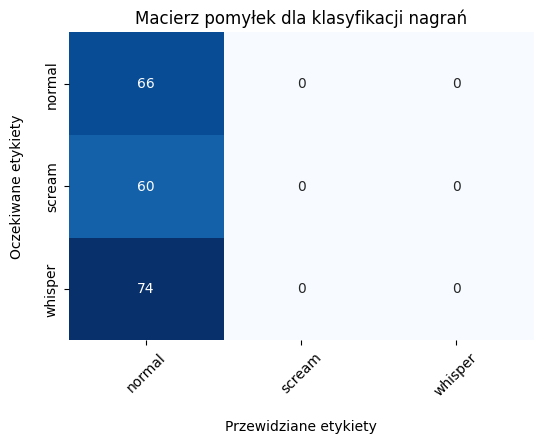

In [11]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

if not FINAL_EVALUATION_MODE:
    train_eval_dummy_classifier(train_ds, val_ds)

# Modelowe rozwiązanie

Poniższe rozwiązanie przechodzi przez cały proces uczenia maszynowego, od eksploracji danych po ewaluację modelu na zbiorze walidacyjnym.
Jako klasyfikator wykorzystano sieć neuronową z warstwami konwolucyjnymi na podstawie przekształcenia danych wejściowych z użyciem spektrogramu.
Do uzyskania dobrych wyników wymagane jest przetworzenie wejściowych danych audio, aby umożliwić skuteczną klasyfikację próbek mowy.

Rozwiązanie zostało podzielone na poszczególne kroki:

* [1. Eksploracja danych](#1.-Eksploracja-danych)
  * [1.1 Podstawowe informacje](#1.1-Podstawowe-informacje)
  * [1.2 Walidacja danych](#1.2-Walidacja-danych)
  * [1.3 Analiza danych](#-1.3-Analiza-danych)
* [2. Inżynieria cech](#2.-Inżynieria-cech)
  * [2.1 Mel-spektrogram](#2.1-Mel-spektrogram)
* [3. Architektura modelu](#3.-Architektura-modelu)
  * [3.1 Warstwy konwolucyjne (convolutional)](#3.1-Warstwy-konwolucyjne)
  * [3.2 Warstwy łączenia (pooling)](#3.2-Warstwy-łączenia)
  * [3.3 Warstwy w pełni połączone (fully-connected)](#3.3-Warstwy-w-pełni-połączone)
* [4. Klasa YourClassifier](#4.-Klasa-YourClassifier)
* [5. Cykl uczenia i ewaluacji](#5.-Cykl-uczenia-i-ewaluacji)
  * [5.1 Wybór hiperparametrów](#5.1-Wybór-hiperparametrów)
  * [5.2 Wybór najlepszego modelu](#5.2-Wybór-najlepszego-modelu)
  * [5.3 Wyniki na zbiorze walidacyjnym (Balanced Accuracy)](#5.3-Wyniki-na-zbiorze-walidacyjnym)
* [6. Bonus - podejście alternatywne](#6.-Bonus---podejście-alternatywne)

## 1. Eksploracja danych
Zanim przejdziemy do implementacji klasyfikatora, zaczniemy od eksploracji danych. Jest to kluczowa część rozwiązywania każdego problemu z zakresu uczenia maszynowego. Eksploracyjna analiza danych (EDA) pozwala na zrozumienie danych treningowych, ich walidację oraz korektę ewentualnych braków i szumów w nich zawartych.

### 1.1 Podstawowe informacje
Zaczynamy od sprawdzenia ogólnych właściwości dostępnych zbiorów danych. Obejmuje to sprawdzenie właściwości takich jak: liczba obserwacji, liczba cech, brakujące wartości.

W przypadku tego zadania, do dyspozycji mamy zestawy danych od razu przetworzone w obiekt dziedziczący po klasie typu `torch.utils.data.Dataset`. Konkretnie:
- `train_ds` - obiekt klasy `WhisperScreamDataset` (zaimplementowany przez autorów zadania) z danymi treningowymi.
- `val_ds` - obiekt klasy `WhisperScreamDataset` (zaimplementowany przez autorów zadania) z danymi walidacyjnymi.

Oba zbiory zawierają próbki audio należące do jednej z trzech klas 0 - normalny głos (`Normal`), 1 - krzyk (`Scream`), 2 - szept (`Whisper`).

In [12]:
# Sprawdzenie ilości obserwacji w zbiorze treningowym i walidacyjnym
print(f'Liczba obserwacji w zbiorze treningowym: {len(train_ds)}')
print(f'Liczba obserwacji w zbiorze walidacyjnym: {len(val_ds)}')


# Sprawdzenie długości próbek audio
max_len = 0

for sample in train_ds:
    audio = sample["audio"]
    if audio.size(-1) > max_len:
        max_len = audio.size(-1)

print(f"Najdłuższe nagranie w zbiorze treningowym ma długość: {max_len} ({max_len / 16000:.1f} sekund)")

Liczba obserwacji w zbiorze treningowym: 2400
Liczba obserwacji w zbiorze walidacyjnym: 200
Najdłuższe nagranie w zbiorze treningowym ma długość: 80000 (5.0 sekund)


In [13]:
# Sprawdzenie braku danych w zbiorach treningowym i walidacyjnym
def check_for_nans(dataset):
    nan_indices = []
    for i in range(len(dataset)):
        try:
            sample = dataset[i]
            audio = sample["audio"]
            
            if torch.isnan(audio).any() or torch.isinf(audio).any():
                nan_indices.append(i)
        except Exception as e:
            print(f"Błąd wczytywania próbki {i}: {e}")
            nan_indices.append(i)
            
    return nan_indices

broken_samples_train = check_for_nans(train_ds)
print(f"Liczba uszkodzonych próbek w zbiorze treningowym: {len(broken_samples_train)}")

broken_samples_val = check_for_nans(val_ds)
print(f"Liczba uszkodzonych próbek w zbiorze walidacyjnym: {len(broken_samples_val)}")

Liczba uszkodzonych próbek w zbiorze treningowym: 0
Liczba uszkodzonych próbek w zbiorze walidacyjnym: 0


In [14]:
# Przykładowe dane
print(train_ds[0])

{'audio': tensor([-0.0174, -0.0017, -0.0036,  ..., -0.0017, -0.0029,  0.0109]), 'label': np.int64(2)}


### 1.2 Walidacja danych

Po wstępnej eskploracji podstawowych właściwości danych, przeprowadzimy walidację danych treningowych i walidacyjnych, aby upewnić się, że są one odpowiednie do dalszej analizy i modelowania. Weryfikacja skupia się na porównaniu rozkładów zmiennej celu w zbiorach danych.

In [15]:
# Porównanie rozkładów zmiennej celu w zbiorze treningowym i walidacyjnym
from collections import Counter

def get_distribution(dataset):
    # Wyciągamy wszystkie etykiety ze zbioru danych
    labels = [sample["label"] for sample in dataset]
    
    counts = Counter(labels)
    total = len(labels)
    
    # Tworzymy słownik z rozkładem procentowym, posortowany po kluczach (klasach)
    return {k: v / total for k, v in sorted(counts.items())}

# Obliczamy rozkłady
train_dist = get_distribution(train_ds)
val_dist = get_distribution(val_ds)

# Wyświetlamy wyniki
print("Rozkład zmiennej celu w zbiorze treningowym:")
for label, prob in train_dist.items():
    print(f"Klasa {label}: {prob:.2f}")

print("\nRozkład zmiennej celu w zbiorze walidacyjnym:")
for label, prob in val_dist.items():
    print(f"Klasa {label}: {prob:.2f}")

Rozkład zmiennej celu w zbiorze treningowym:
Klasa 0: 0.33
Klasa 1: 0.33
Klasa 2: 0.33

Rozkład zmiennej celu w zbiorze walidacyjnym:
Klasa 0: 0.33
Klasa 1: 0.30
Klasa 2: 0.37


Rozkłady zmiennej docelowej w zbiorze treningowym i walidacyjnym są do siebie zbliżone.

Proporcje klas na zbiorze treningowym są idealnie zbalansowane. W przypadku zbioru walidacyjnego zauważamy nieznaczne odchylenie w klasie 1 (krzyk) na rzecz klasy 2 (szept), nie jest to jednak duże odchylenie. W związku z tym, możemy założyć, że nie będzie konieczne użycie metod wyrównania (rebalansingu) liczności klas.

### 1.3 Analiza danych

Przyjrzymy się bliżej danym audio jakimi dysponujemy w tym zadaniu. Sprawdzimy, jak dla każdej z poszczególnych klas wyglądają zagregowane wartości cech audio takich jak:
- *Średnia / maksymalna amplituda* - określa odpowiednio ogólny oraz szczytowy poziom sygnału dźwiękowego w czasie, co pozwala ocenić głośność oraz dynamikę nagrania. Ponieważ dane w zadaniu zostały znormalizowane do stałego poziomu głośności, analiza ta służy jako walidacja preprocessingu oraz pozwala zbadać różnice w dynamice (stosunek wartości szczytowej do średniej), które powinny pozostać widoczne mimo ujednolicenia energii sygnału.

- *Średni / maksymalny profil widmowy* - przedstawia uśredniony / szczytowy rozkład mocy sygnału w funkcji częstotliwości, co pozwala zidentyfikować dominujące pasma charakterystyczne dla danej klasy dźwięku.

- *Zero-crossing rate (ZCR)* - miara, jak często fala dźwiękowa przecina oś zero w jednostce czasu.

Analizowanie próbek audio...


100%|██████████| 2400/2400 [00:00<00:00, 12733.05it/s]


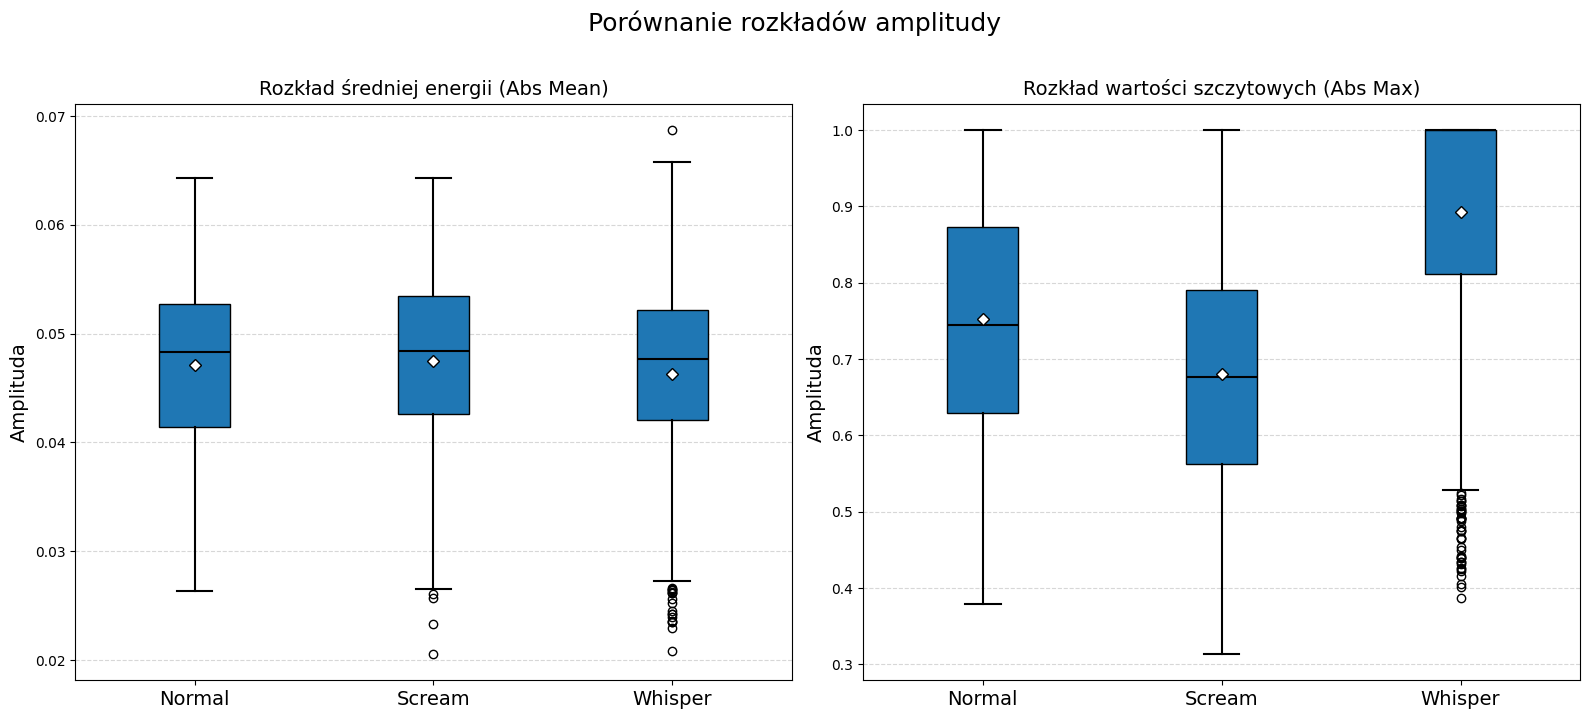

In [16]:
# Średnia / maksymalna amplituda nagrań w zależności od klasy
classes_map = {0: "Normal", 1: "Scream", 2: "Whisper"}
labels_ordered = ["Normal", "Scream", "Whisper"]
raw_stats = {name: {"means": [], "maxs": []} for name in classes_map.values()}

# Zbieranie danych ze wszystkich próbek
print("Analizowanie próbek audio...")
for i in tqdm(range(len(train_ds))):
    sample = train_ds[i]
    audio_abs = sample["audio"].abs()
    label_name = classes_map[int(sample["label"])]
    raw_stats[label_name]["means"].append(audio_abs.mean().item())
    raw_stats[label_name]["maxs"].append(audio_abs.max().item())

# Przygotowanie list do boxplota
means_data = [raw_stats[name]["means"] for name in labels_ordered]
maxs_data = [raw_stats[name]["maxs"] for name in labels_ordered]

# Wizualizacja
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

def style_boxplot(bp, ax, title, ylabel):
    for element in ['whiskers', 'caps', 'medians']:
        plt.setp(bp[element], color='black', linewidth=1.5)
    
    ax.set_title(title, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xticklabels(labels_ordered, fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Wykres 1: Średnia amplituda (Energia)
bp1 = ax1.boxplot(means_data, patch_artist=True, showmeans=True,
                  meanprops={"marker":"D","markerfacecolor":"white", "markeredgecolor":"black", "markersize":6})
style_boxplot(bp1, ax1, 'Rozkład średniej energii (Abs Mean)', 'Amplituda')

# Wykres 2: Maksymalna amplituda (Szczyt)
bp2 = ax2.boxplot(maxs_data, patch_artist=True, showmeans=True,
                  meanprops={"marker":"D","markerfacecolor":"white", "markeredgecolor":"black", "markersize":6})
style_boxplot(bp2, ax2, 'Rozkład wartości szczytowych (Abs Max)', 'Amplituda')

plt.suptitle('Porównanie rozkładów amplitudy', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

Analiza wykresów potwierdza, że dane zostały poddane normalizacji głośności, co zrównało średnią energię wszystkich klas. Natomiast, prawy wykres pokazuje znaczne różnice w szczytowych amplitudach, co jest zgodne z przewidywaniami, bo wartości maksymalne dźwięków muszą się róźnić aby zachować tę samą energię średnią. 

Zaskakująco wysoka amplituda maksymalna szeptu przy jednocześnie najniższych pikach krzyku sugeruje, że szept zawiera gwałtowne skoki impulsowe, podczas gdy krzyk charakteryzuje się sygnałem silnie skompresowanym i gęstym.

100%|██████████| 2400/2400 [00:00<00:00, 5694.58it/s]


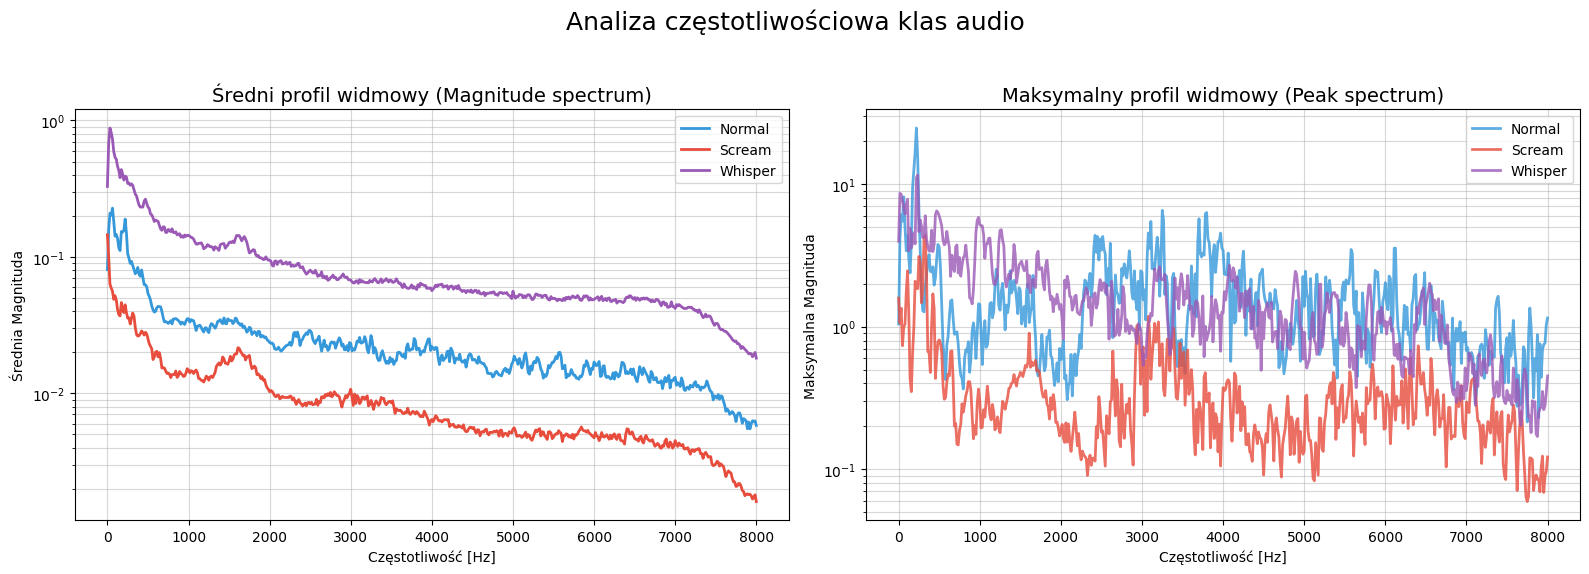

In [17]:
# Średni / maksymalny profil widmowy w zależności od klasy
def calculate_spectral_profiles(dataset, classes_map, n_fft=1024):
    """
    Oblicza średni i maksymalny profil widmowy dla każdej klasy w zbiorze.
    """
    spectral_data = {label: [] for label in classes_map.values()}
    sr = 16000
    freqs = np.linspace(0, sr / 2, n_fft // 2 + 1)

    for i in tqdm(range(len(dataset))):
        sample = dataset[i]
        audio = sample["audio"]
        label = classes_map[int(sample["label"])]
        
        # Obliczamy magnitudę FFT (używamy okna Hamminga dla lepszej separacji)
        window = torch.hamming_window(n_fft)
        
        # Jeśli audio jest krótsze niż n_fft, dopełniamy zerami
        if audio.size(-1) < n_fft:
            audio = torch.nn.functional.pad(audio, (0, n_fft - audio.size(-1)))
        
        # Wycinamy fragment sygnału (początek) i nakładamy okno Hamminga,
        # aby zminimalizować błędy brzegowe (leakage) przed transformacją FFT.
        spec = torch.fft.rfft(audio[:n_fft] * window)
        magnitude = torch.abs(spec)
        
        spectral_data[label].append(magnitude.numpy())

    # Agregacja wyników
    results = {}
    for label, specs in spectral_data.items():
        specs_array = np.array(specs)
        results[label] = {
            "mean": np.mean(specs_array, axis=0),
            "max": np.max(specs_array, axis=0)
        }
    
    return freqs, results

# Wizualizacja
classes_map = {0: "Normal", 1: "Scream", 2: "Whisper"}
freqs, profiles = calculate_spectral_profiles(train_ds, classes_map)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = {"Normal": "#3498db", "Scream": "#e74c3c", "Whisper": "#9b59b6"}

for label, data in profiles.items():
    # Wykres średniego widma
    ax1.plot(freqs, data["mean"], label=label, color=colors[label], lw=2)
    # Wykres maksymalnego widma
    ax2.plot(freqs, data["max"], label=label, color=colors[label], lw=2, alpha=0.8)

# Wykres 1 (Średnie)
ax1.set_title("Średni profil widmowy (Magnitude spectrum)", fontsize=14)
ax1.set_xlabel("Częstotliwość [Hz]")
ax1.set_ylabel("Średnia Magnituda")
ax1.set_yscale('log') # Skala logarytmiczna lepiej oddaje percepcję słuchu
ax1.grid(True, which="both", ls="-", alpha=0.5)
ax1.legend()

# Wykres 2 (Max)
ax2.set_title("Maksymalny profil widmowy (Peak spectrum)", fontsize=14)
ax2.set_xlabel("Częstotliwość [Hz]")
ax2.set_ylabel("Maksymalna Magnituda")
ax2.set_yscale('log')
ax2.grid(True, which="both", ls="-", alpha=0.5)
ax2.legend()

plt.suptitle("Analiza częstotliwościowa klas audio", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Analiza profilu widmowego ujawnia, że szept (`Whisper`) dominuje pod względem energii w całym paśmie częstotliwości. Mowa normalna wykazuje charakterystyczne wzmocnienia energii w niskich częstotliwościach oraz wyraźne piki formantowe, podczas gdy krzyk (`Scream`) posiada paradoksalnie najniższą średnią amplitudę spektralną. Tak wyraźna separacja średnich profilów widmowych stanowi solidną podstawę merytoryczną dla wysokiej skuteczności klasyfikatora opartego na częstotliwości jako predyktorze. W przypadku maksymalnego profilu widmowego, różnice pozostają dalej widoczne, natomiast magnitudy zaczynają się ze sobą przeplatać.

100%|██████████| 2400/2400 [00:00<00:00, 5408.76it/s]
C:\Users\48601\AppData\Local\Temp\ipykernel_9632\3061550648.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data_to_plot, labels=labels_ordered, patch_artist=True,


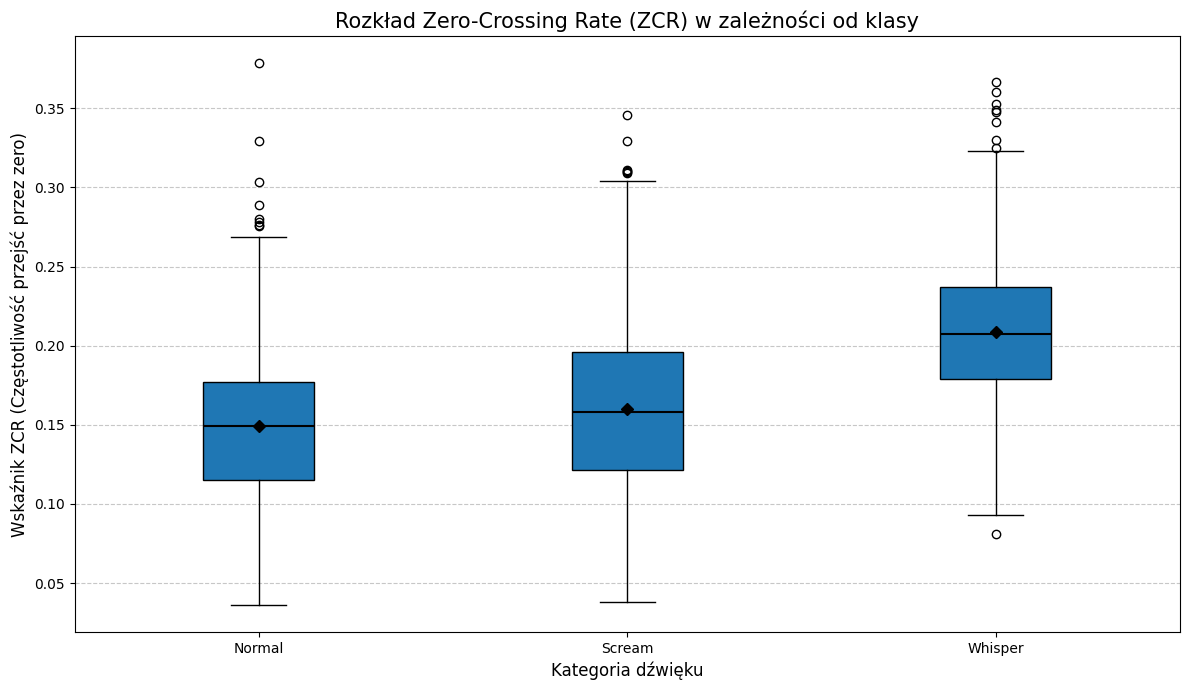

In [18]:
# Zero-Crossing Rate (ZCR) w zależności od klasy
def calculate_zcr(audio_tensor):
    """
    Oblicza Zero-Crossing Rate dla tensora audio.
    ZCR = (liczba zmian znaku) / (liczba próbek - 1)
    """
    zero_crossings = torch.diff(torch.sign(audio_tensor)).abs() > 0
    return zero_crossings.sum().item() / (audio_tensor.size(-1) - 1)

classes_map = {0: "Normal", 1: "Scream", 2: "Whisper"}
labels_ordered = ["Normal", "Scream", "Whisper"]
zcr_collections = {name: [] for name in labels_ordered}

for i in tqdm(range(len(train_ds))):
    sample = train_ds[i]
    audio = sample["audio"]
    label_name = classes_map[int(sample["label"])]
    
    zcr_val = calculate_zcr(audio)
    zcr_collections[label_name].append(zcr_val)

data_to_plot = [zcr_collections[name] for name in labels_ordered]

# Wizualizacja
plt.figure(figsize=(12, 7))
plt.grid(axis='y', linestyle='--', alpha=0.7)

box = plt.boxplot(data_to_plot, labels=labels_ordered, patch_artist=True, 
                  medianprops=dict(color="black", linewidth=1.5),
                  showmeans=True, meanprops=dict(marker='D', markeredgecolor='black', markerfacecolor='black'))


plt.title("Rozkład Zero-Crossing Rate (ZCR) w zależności od klasy", fontsize=15)
plt.ylabel("Wskaźnik ZCR (Częstotliwość przejść przez zero)", fontsize=12)
plt.xlabel("Kategoria dźwięku", fontsize=12)
plt.tight_layout()
plt.show()

Wykres Zero-Crossing Rate (ZCR) wskazuje na najwyższą częstotliwość przejść przez zero w przypadku szeptu, co potwierdza jego szumową naturę. Klasy mowy normalnej i krzyku wykazują niższe i zbliżone do siebie mediany ZCR, co świadczy o ich bardziej harmonicznym charakterze, wynikającym z regularnych drgań strun głosowych.


Analiza różnorodnych cech fizycznych sygnału wykazała, że każda z klas posiada unikalną charakterystykę w dziedzinie częstotliwości i dynamiki. Aby skumulować te kluczowe informacje w jednej, czytelnej dla modelu reprezentacji wizualnej, posłużymy się spektrogramem - o tym w następnej sekcji.

## 2. Inżynieria cech

Aby skutecznie wykorzystywać dane sekwencyjne audio do uczenia maszynowego, często wykorzystuje się transformacje tych danych. Do najpopularniejszych metod ekstrakcji cech z danych audio zalicza się spektrogram. W procesie przygotowania danych w modelowym rozwiązaniu wykorzystano jeden z jego wariantów - **Mel-spektrogram**.

### 2.1 Mel-spektrogram

Mel-spektrogram to wizualna reprezentacja sygnału dźwiękowego, która łączy informacje o czasie, częstotliwości oraz natężeniu dźwięku. W odróżnieniu od klasycznego spektrogramu, oś częstotliwości zostaje tu przekształcona na nieliniową skalę melową. Skala ta została zaprojektowana tak, aby odzwierciedlać ludzką percepcję słuchu – jesteśmy bardziej czuli na zmiany w niższych częstotliwościach niż w wyższych.

Proces generowania spektrogramu przebiega w następujących krokach:
1. Sygnał jest dzielony na krótkie, nakładające się ramki czasowe.
2. Dla każdej ramy obliczana jest Krótkoczasowa Transformata Fouriera ([Short-Time Fourier Transform](https://en.wikipedia.org/wiki/Short-time_Fourier_transform) lub w skrócie STFT) z wykorzystaniem okna o rozmiarze $n_{fft} = 1024$. Pozwala to na uzyskanie informacji o zawartości częstotliwościowej w konkretnych momentach czasu.
3.  Uzyskane widmo mocy jest przepuszczane przez zestaw trójkątnych filtrów (tzw. Mel filter banks), które agregują energię w odpowiednich pasmach częstotliwości. Najczęściej stosowaną przybliżoną formułą skali Mel jest:
$$F_{Mel}(x) = 2595 \cdot \log_{10}\left(1 + \frac{x}{700}\right)$$


W efekcie otrzymujemy dwuwymiarową macierz, gdzie:
* Oś pozioma (x) reprezentuje czas.
* Oś pionowa (y) reprezentuje kanały melowe (częstotliwość).
* Wartość punktu (amplituda) określa energię dźwięku w danym paśmie i czasie (zazwyczaj wyrażoną w skali logarytmicznej decybeli).

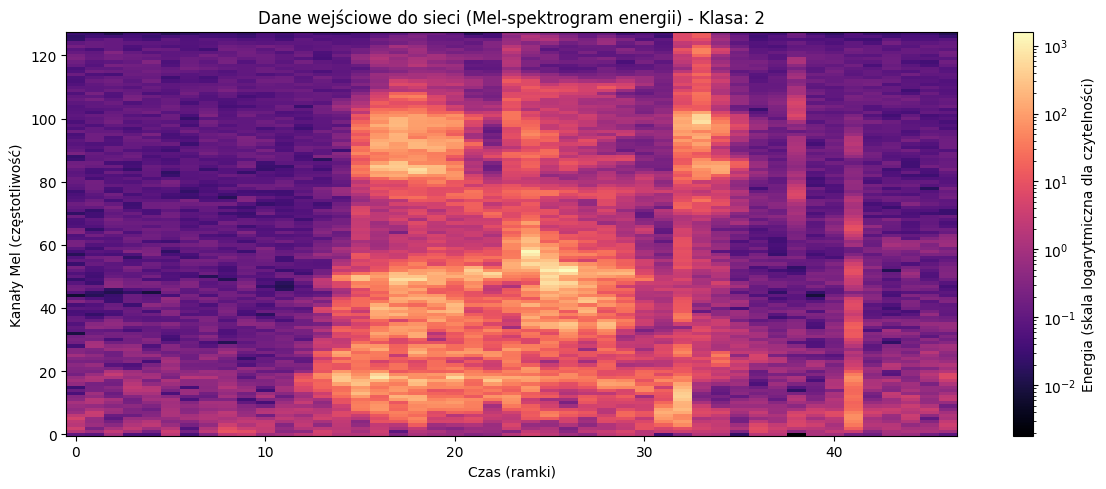

Zakres wartości energii: od 1.80e-03 do 1.60e+03


In [19]:
import torchaudio.transforms as T
from matplotlib.colors import LogNorm

# Pobranie próbki i przygotowanie transformacji
sample = train_ds[0]
audio = sample["audio"]
label = sample["label"]

# Inicjalizacja transformacji
transform = torchaudio.transforms.MelSpectrogram(n_fft=1024)

# Przetworzenie audio do formatu oczekiwanego przez transformację
if audio.dim() == 1:
    audio = audio.unsqueeze(0)

# Generujemy spektrogram energii
mel_spec = transform(audio) 

# Wizualizacja
plt.figure(figsize=(12, 5))

# Używamy LogNorm tylko do "wyciągnięcia" detali na obrazku, 
# nie zmieniając samych danych w tensorze mel_spec.
img = plt.imshow(
    mel_spec[0].numpy(), 
    origin='lower', 
    aspect='auto', 
    cmap='magma',
    norm=LogNorm() # Dzięki temu zobaczymy subtelniejsze różnice w energii
)

plt.title(f"Dane wejściowe do sieci (Mel-spektrogram energii) - Klasa: {label}")
plt.xlabel("Czas (ramki)")
plt.ylabel("Kanały Mel (częstotliwość)")
plt.colorbar(img, label="Energia (skala logarytmiczna dla czytelności)")
plt.tight_layout()
plt.show()

print(f"Zakres wartości energii: od {mel_spec.min().item():.2e} do {mel_spec.max().item():.2e}")

Przekształcenie wejściowych danych audio do tego formatu pozwala na wykorzystanie potężnego rozwiązania z zakresu wizji komputerowej - konwolucyjnej sieci neuronowej.

## 3. Architektura modelu

Rdzeniem zaproponowanego modelowego rozwiązania jest konwolucyjna sieć neuronowa. Poniższy diagram przedstawia schemat całej archiektury modelu. W następnych podsekcjach zostaną dokładnie omówione poszczególne komponenty architektury modelowego rozwiązania.

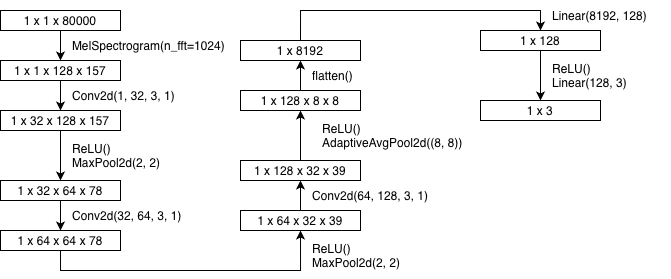

*Obraz wygenerowany przez narzędzie generowania diagramów, stworzony przez autorów zadania.*

### 3.1 Warstwy konwolucyjne
Głównym zadaniem warstw konwolucyjnych (splotowych) jest automatyczna ekstrakcja cech z Mel-spektrogramu. W przeciwieństwie do klasycznych warstw pełni połączoncyh (gęstych), warstwy splotowe zachowują relacje przestrzenne między sąsiednimi częstotliwościami i ramkami czasowymi.

Podstawową operacją tej warstwy jest konwolucja (splot) - matematyczna operacja, która skupia się na konkretnym oknie wejściowego obrazu. Działanie warstwy konwolucyjnej opiera się na przesuwaniu tego okna obliczeniowego nad sygnałem. Proces ten definiują trzy główne parametry:
* Filtr / jądro  (*kernel*) - macierz wag, która przesuwa się nad spektrogramem. Definiuje rozmiary okna, wewnątrz którego wykrywamy specyficzne wzorce i lokalne zależności.

* Krok (*stride*) - liczba określająca o ile jednostek (pikseli/punktów) przesuwa się filtr po każdym kroku obliczeń. Stride o wartości 1 oznacza, że filtr przesuwa się o jeden rząd / kolumnę po każdym obliczeniu.

* Wypełnienie (*padding*) - dodanie dodatkowych ramek (domyślnie o wartości 0) wokół krawędzi wejściowego spektrogramu przed nałożeniem filtra. Pozwala to jądru (kernel) na "wyjście" poza oryginalny obszar danych, dzięki czemu piksele brzegowe mogą znaleźć się w centrum okna filtra. Bez paddingu każda operacja konwolucji powodowałaby zmniejszenie wymiarów obrazu, a informacje na samych krawędziach byłyby przetwarzane rzadziej niż te w środku.


Dla wejściowego spektrogramu $I$ oraz macierzy filtru $K$ o rozmiarze $(m \times n)$, wartość w punkcie $(i, j)$ mapy cech wyjściowej $S$ obliczana jest według wzoru:
$$S(i, j) = (I * K)(i, j) = \sum_{m} \sum_{n} I(i+m, j+n) \cdot K(m, n)$$

Po każdej operacji konwolucji stosowana jest nieliniowa funkcja aktywacji. Najczęściej jest to ReLU (Rectified Linear Unit):
$$ReLU(x) = \max(0, x)$$

W opracowanym modelu zastosowano trzy bloki konwolucyjne, które stopniowo zwiększają liczbę filtrów, pozwalając na wykrywanie coraz bardziej złożonych wzorców:
1. Warstwa Conv1: 32 filtry o rozmiarze $3 \times 3$. Służy do wykrywania podstawowych krawędzi i nagłych zmian energii.
2. Warstwa Conv2: 64 filtry o rozmiarze $3 \times 3$. Łączy proste cechy w bardziej złożone struktury.
3. Warstwa Conv3: 128 filtrów o rozmiarze $3 \times 3$. Ekstrahuje wysokopoziomowe cechy abstrakcyjne.

W każdej z warstw zastosowano padding oraz stride, równe 1. W poniższym wycinku kodu wykorzystamy na razie jedynie warstwy konwolucyjne z funkcjami aktywacji, bez warstw łączenia (pooling layers). Ich wpływ zobrazujemy w następnej sekcji.

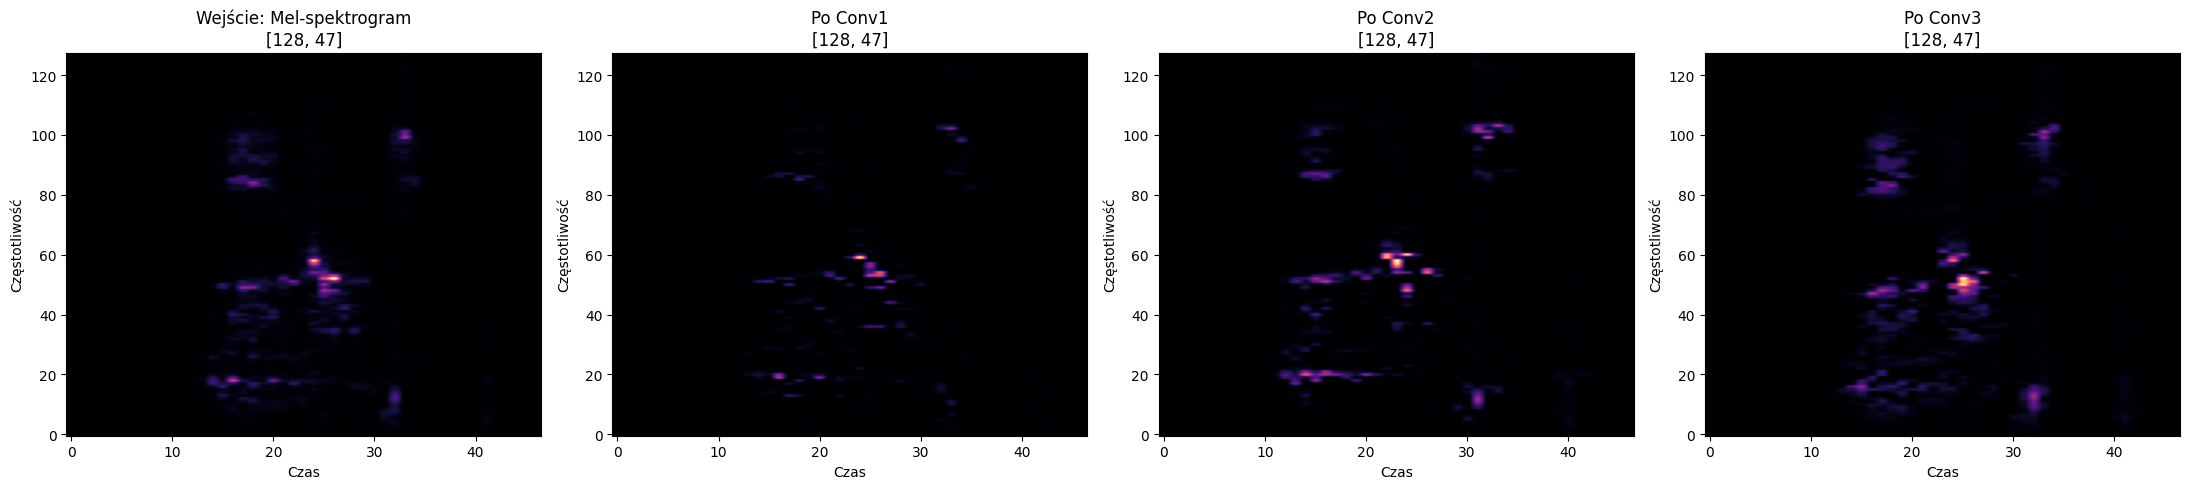

In [20]:
import torch.nn.functional as F

# Przygotowanie danych wejściowych - weźmy pierwszą próbkę z train_ds
sample = train_ds[0]
audio = sample["audio"]
if audio.dim() == 1:
    audio = audio.unsqueeze(0)

# Definicja samych warstw konwolucyjnych (na razie bez poolingu)
# Używamy identycznych parametrów jak w modelowym rozwiązaniu
n_fft = 1024
transform = T.MelSpectrogram(n_fft=n_fft, sample_rate=16000)

conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

# Przepływ sygnału
with torch.no_grad():
    # Etap 0: Spektrogram
    x0 = transform(audio)
    if x0.dim() == 3:
        x0 = x0.unsqueeze(1)
    
    # Etap 1: Conv1 + ReLU
    x1 = F.relu(conv1(x0))
    
    # Etap 2: Conv2 + ReLU
    x2 = F.relu(conv2(x1))
    
    # Etap 3: Conv3 + ReLU
    x3 = F.relu(conv3(x2))

# Wizualizacja
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

def render_conv_stage(tensor, ax, title):
    data = tensor[0, 0].detach().cpu().numpy()
    ax.imshow(data, origin='lower', aspect='auto', cmap='magma')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Czas")
    ax.set_ylabel("Częstotliwość")

render_conv_stage(x0, axes[0], f"Wejście: Mel-spektrogram\n{list(x0.shape[2:])}")
render_conv_stage(x1, axes[1], f"Po Conv1\n{list(x1.shape[2:])}")
render_conv_stage(x2, axes[2], f"Po Conv2\n{list(x2.shape[2:])}")
render_conv_stage(x3, axes[3], f"Po Conv3\n{list(x3.shape[2:])}")

plt.tight_layout()
plt.show()

### 3.2 Warstwy łączenia

Podczas gdy warstwy konwolucyjne odpowiadają za wykrywanie cech, zadaniem warstw łączenia (pooling) jest redukcja wymiarowości map tych cech przy jednoczesnym zachowaniu najistotniejszych informacji. Proces ten nazywany jest próbkowaniem w dół (*downsampling*).

Zastosowanie warstw poolingu w modelu klasyfikacji audio przynosi trzy kluczowe korzyści:

1. Niezmienniczość względem przesunięć - model staje się odporny na to, w którym dokładnie momencie nagrania wystąpił krzyk czy szept. Ważne jest "co" było w danych, a nie idealnie "kiedy" w skali milisekundowej.
2. Redukcja kosztu obliczeniowego - zmniejszenie liczby parametrów w głębszych warstwach sieci przyspiesza proces trenowania i ogranicza ryzyko przeuczenia (overfitting).
3. Zwiększenie pola recepcyjnego - dzięki zmniejszeniu wymiarów, kolejne filtry konwolucyjne mogą analizować większy obszar oryginalnego spektrogramu.

Wyróżniamy dwa główne typy tych warstw, które wykorzystano w modelu:
* **Max Pooling** - działa analogicznie do filtru konwolucyjnego, ale zamiast mnożenia wag, wybiera maksymalną wartość z danego okna (np. $2 \times 2$). W kontekście spektrogramu pozwala to na wyodrębnienie najbardziej dominujących cech, takich jak nagłe skoki energii charakterystyczne dla krzyku.
* **Adaptive Average Pooling** - w przeciwieństwie do standardowego poolingu, gdzie definiujemy rozmiar okna, tutaj definiujemy rozmiar wyjściowy (w naszym modelu jest to $8 \times 8$). Warstwa ta **uśrednia** wszystkie wartości z mapy cech do zdefiniowanego rozmiaru - $8 \times 8$ punktów. Jest to kluczowy element architektury, który generuje na wyjściu zawsze ten sam stały rozmiar wektora dla warstw pełni połączonych.

W opracowanym modelu struktura bloków wygląda następująco:
* Po pierwszej i drugiej warstwie konwolucyjnej zastosowano Max Pooling o rozmiarze $2\times2$ (stride $= 2$), co redukuje wymiar mapy cech o połowę po każdym bloku.
* Po trzeciej warstwie konwolucyjnej zastosowano Adaptive Average Pooling o rozmiarze okna $8\times8$, aby zwinąć całą informację przestrzenną i czasową do globalnego wektora cech przed ostateczną klasyfikacją.

Zobaczmy, jak zmienia się wygląd spektrogramu z poprzedniego punktu, przy zastosowaniu warstw łączenia po każdej z warstw konwolucyjnych.

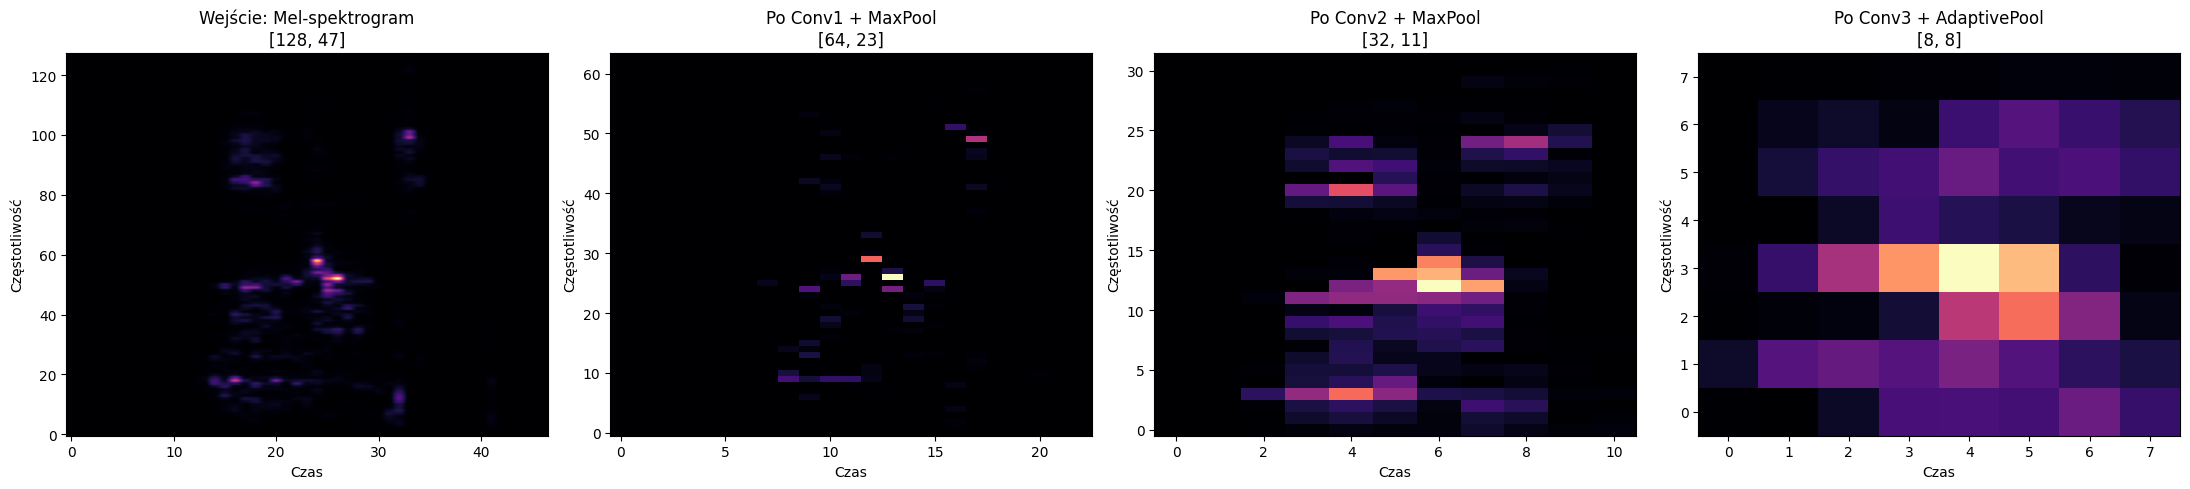

In [21]:
# Przygotowanie danych wejściowych - tak samo jak w 3.1
sample = train_ds[0]
audio = sample["audio"]
if audio.dim() == 1:
    audio = audio.unsqueeze(0)

n_fft = 1024
transform = T.MelSpectrogram(n_fft=n_fft, sample_rate=16000)

# Warstwy Konwolucyjne
conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

# Warstwy Poolingu
pool_max = nn.MaxPool2d(kernel_size=2, stride=2)
pool_adaptive = nn.AdaptiveAvgPool2d((8, 8))

# Przepływ sygnału (Konwolucja + ReLU + Pooling)
with torch.no_grad():
    # Etap 0: Wejściowy spektrogram
    x0 = transform(audio)
    if x0.dim() == 3:
        x0 = x0.unsqueeze(1)
    
    # Etap 1: Conv1 + ReLU + MaxPool (wymiary / 2)
    x1_conv = F.relu(conv1(x0))
    x1 = pool_max(x1_conv)
    
    # Etap 2: Conv2 + ReLU + MaxPool (wymiary / 2)
    x2_conv = F.relu(conv2(x1))
    x2 = pool_max(x2_conv)
    
    # Etap 3: Conv3 + ReLU + AdaptivePool (wymiary -> 8x8)
    x3_conv = F.relu(conv3(x2))
    x3 = pool_adaptive(x3_conv)

# Wizualizacja
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

def render_stage(tensor, ax, title):
    data = tensor[0, 0].detach().cpu().numpy()
    ax.imshow(data, origin='lower', aspect='auto', cmap='magma')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Czas")
    ax.set_ylabel("Częstotliwość")

render_stage(x0, axes[0], f"Wejście: Mel-spektrogram\n{list(x0.shape[2:])}")
render_stage(x1, axes[1], f"Po Conv1 + MaxPool\n{list(x1.shape[2:])}")
render_stage(x2, axes[2], f"Po Conv2 + MaxPool\n{list(x2.shape[2:])}")
render_stage(x3, axes[3], f"Po Conv3 + AdaptivePool\n{list(x3.shape[2:])}")

plt.tight_layout()
plt.show()

Przy tej samej skali częstotliwości, zauważamy znaczne różnice w wydobyciu lokalnych silnych sygnałów, a także ich uśrednienie na bardziej ogólnym obszarze. Po przejściu przez ostatnią warstwę - adaptive poolingu, dane zostają przekazane do warstw w pełni połączonych, aby skutecznie przeprowadzić uczenie na zadaniu klasyfikacji.

### 3.3 Warstwy w pełni połączone

Warstwy w pełni połączone (*Fully connected*) stanowią końcowy etap architektury klasyfikatora. Ich zadaniem jest przeprowadzenie ostatecznego wnioskowania na podstawie cech wysokopoziomowych dostarczonych przez część konwolucyjną modelu.

**Proces wypłaszczania (*Flattening*)**. Zanim dane trafią do warstw liniowych, muszą zostać przekształcone z wielowymiarowych map cech do postaci jednowymiarowego wektora.  Po przejściu przez Adaptive pooling o rozmiarze wyjściowym $8\times8$, dane mają kształt `(Batch, 128, 8, 8)`. Wypłaszczenie zamienia je w wektor o długości $128 \times 8 \times 8 = 8192$ elementów dla każdej próbki w paczce.


W modelowym rozwiązaniu wykorzystano dwie warstwy w pełni połączone:

1. **Warstwa FC1 (in=8192, out=128):** Ta warstwa pełni rolę agregatora informacji. Łączy ona 8192 cechy przestrzenne i częstotliwościowe w 128 bardziej abstrakcyjnych "sygnałów". Pozwala to sieci zrozumieć korelacje między różnymi obszarami spektrogramu (np. jednoczesne występowanie wysokiej energii w wysokich tonach i ciszy w niskich). Pomiędzy warstwami liniowymi zastosowano opisaną wyżej funkcję aktywacji `ReLU`.
3. **Warstwa FC2 (in=128, out=3):** Jest to warstwa wyjściowa, która mapuje 128 przetworzonych cech na 3 finalne klasy (szept, mowa, krzyk). Każde z trzech wyjść generuje tzw. *logit*, którego wartość określa pewność modelu co do przynależności do danej kategorii.

W przeciwieństwie do konwolucji, które patrzą na dane lokalnie, warstwy w pełni połączone mają **globalne pole widzenia**. Widzą całe "streszczenie" nagrania naraz. Warto zauważyć, że przejście z 8192 do 128 neuronów jest formą znacznej kompresji informacji – model musi zdecydować, które z wyekstrahowanych cech spektrogramu są kluczowe dla rozróżnienia szeptu od krzyku, a które są jedynie nieistotnym szumem.

Poniżej przedstawiono przykładowy output zaprojektowanej architektury dla wcześniej wykorzystywanej próbki audio z danych treningowych. Na wyjściu model sieci neuronowej podaje wartości każdej z 3 klas. ***Uwaga:*** uściślając, w modelowym rozwiązaniu klasyfikator nie zwraca prawdopodobieństw, a *logity*. Mówiąc ogólnie, logit to surowy wynik modelu, podczas gdy prawdopodobieństwo to ten sam wynik przeskalowany do czytelniejszej formy. Dla łatwiejszego zobrazowania działania architektury, w poniższym wycinku kodu zastosowano skalowanie outputu modelu za pomocą funkcji aktywacji `softmax`. Funkcja ta nie jest używana w modelowym rozwiązaniu.

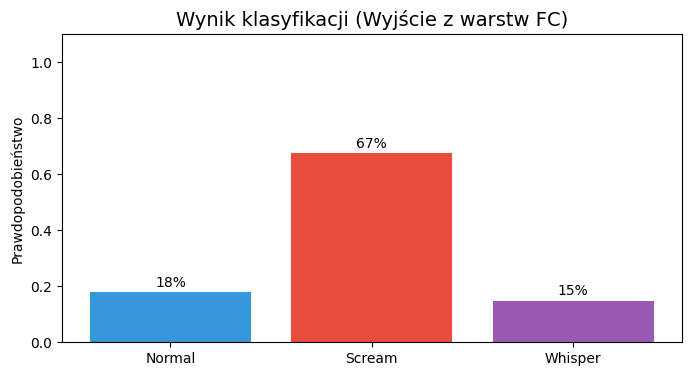

In [22]:
# Przepływ przez warstwy FC (ciąg dalszy po 3.2)
# Definicja warstw FC zgodnie z modelowym rozwiązaniem
fc1 = nn.Linear(128 * 8 * 8, 128)
fc2 = nn.Linear(128, 3) # 3 klasy: normal, scream, whisper

with torch.no_grad():
    # Wypłaszczamy dane po Adaptive Poolingu
    x_flat = x3.view(x3.size(0), -1) 

    x_fc1 = F.relu(fc1(x_flat))
    logits = fc2(x_fc1)
    
    # Zamiana logitów na prawdopodobieństwo (0-100%) dla lepszej wizualizacji
    # w modelowym rozwiązaniu nie ma funkcji softmax, tutaj wykorzystana jest do wizualizacji
    probabilities = F.softmax(logits, dim=1).cpu().numpy()[0]

# Wizualizacja końcowej decyzji
labels = ['Normal', 'Scream', 'Whisper']
plt.figure(figsize=(8, 4))
plt.bar(labels, probabilities, color=['#3498db', '#e74c3c', '#9b59b6'])
plt.title("Wynik klasyfikacji (Wyjście z warstw FC)", fontsize=14)
plt.ylabel("Prawdopodobieństwo")
plt.ylim(0, 1.1) # Skala 0-100%

# Dodanie wartości procentowych nad słupkami
for i, val in enumerate(probabilities):
    plt.text(i, val + 0.02, f'{val*100:.0f}%', ha='center')

plt.show()

Próbka audio, na której obrazowane są elementy architektury w tej sekcji, jest z klasy szeptu (*Whisper*). Jak widzimy, model bez odpowiedniego treningu nie jest w stanie tego rzetelnie przewidzieć - w zasadzie zgaduje tylko na **podstawie zainicjalizowanych losowo wag** w warstwach sieci neuronowej. Właśnie dlatego kluczowy jest odpowiedni proces trenowania sieci neuronowej, aby nauczyła się ona rozpoznawać różnice między klasami na podstawie danych treningowych.

### 4. Klasa `YourClassifier`

Klasa `YourClassifier` stanowi serce modelowego rozwiązania problemu klasyfikacji sygnałów dźwiękowych. Została zaprojektowana jako model przetwarzający surowe dane audio do postaci spektralnej, a następnie wykorzystujący hierarchiczną ekstrakcję cech za pomocą warstw konwolucyjnych, łączenia i w pełni połączonych w celu automatycznego rozpoznania kategorii sygnału.

### Skład i struktura klasy

Architektura została podzielona na moduły odpowiedzialne za transformację dziedzinową, ekstrakcję cech przestrzennych oraz decyzyjne warstwy liniowe:

* **Moduł transformacji czasowo-częstotliwościowej:**
    * `self.transform` (`MelSpectrogram`): Przekształca surową falę dźwiękową (1D) w dwuwymiarową reprezentację spektralną (Mel-spektrogram). Wykorzystanie skali Mel pozwala modelowi skupić się na cechach dźwięku istotnych z punktu widzenia ludzkiej percepcji, co jest kluczowe przy rozróżnianiu barwy szeptu od mowy.


* **Ekstrakcja cech:**
    * `self.conv1` / `self.conv2` / `self.conv3`: Zestaw trzech warstw konwolucyjnych o rosnącej liczbie kanałów $(32, 64, 128)$. Warstwy te pełnią rolę detektorów wzorców: od prostych zmian energii w pasmach częstotliwości, po złożone struktury harmoniczne.

* **Agregacja i normalizacja wymiarów:**
     * `self.pool` (`MaxPool2d`): Warstwa redukująca wymiarowość, która zapewnia niezmienniczość modelu względem niewielkich przesunięć w czasie. Pozwala to sieci skupić się na samym wystąpieniu zdarzenia dźwiękowego, a nie na jego dokładnej pozycji w oknie czasowym.
    * `self.avgpool` (`AdaptiveAvgPool2d`):  Warstwa agregująca, która sprowadza mapy cech do stałego rozmiaru $8\times8$, uśredniając lokalne informacje z każdego regionu.


* **Klasyfikator końcowy:**
    * `self.fc1` / `self.fc2`: Warstwy w pełni połączone, które przeprowadzają syntezę $8192$ wyekstrahowanych cech:
        * `self.fc1`: Redukuje przestrzeń cech do $128$ wysokopoziomowych deskryptorów przy użyciu nieliniowej aktywacji ReLU.
        * `self.fc2`: Generuje końcowe wartości (logity) dla trzech klas docelowych, umożliwiając podjęcie decyzji o typie nagrania.


* **Przepływ danych i inferencja:**
    * `forward()`: Implementuje pełną ścieżkę obliczeniową — od normalizacji wymiarów tensora wejściowego, przez generowanie spektrogramu, po kolejne bloki splotowe i operację wypłaszczania (*flattening*).
    * `predict()`: Metoda do wykonania predykcji na próbce danych. Zawiera wbudowaną logikę wyrównywania długości sygnału (`padding` / `cropping`) do parametru `max_len`, przełącza model w tryb ewaluacji (`eval`) i zwraca listę etykiet klasy, przewidzianą przez klasyfikator.

In [23]:
torch.manual_seed(seed)

class YourClassifier(nn.Module):
    """
    Klasyfikator sygnałów audio (szept, mowa, krzyk) oparty na architekturze 
    konwolucyjnych sieci neuronowych i przetwarzania spektrogramów.
    """
    
    def __init__(self, max_len: int, n_fft: int = 1024, n_classes: int = 3):
        super(YourClassifier, self).__init__()
        
        self.max_len = max_len
        
        # [2.1 Mel-spektrogram]
        self.transform = T.MelSpectrogram(
            n_fft=n_fft, 
            sample_rate=16000 # Zakładamy 16 kHz - z treści zadania
        )
        
        # [3.1 Warstwy konwolucyjne]
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # [3.2 Warstwy łączenia]
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((8, 8))
        
        # [3.3 Warstwy w pełni połączone]
        self.fc1 = nn.Linear(128 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, audio: torch.Tensor) -> torch.Tensor:
        """
        Przepływ tensora przez architekturę sieci (Forward pass).
        """
        # Standaryzacja wymiarów: zapewnienie obecności wymiaru Batch [Batch, Time]
        if audio.dim() == 1:
            audio = audio.unsqueeze(0) 
        
        # Transformacja audio do dziedziny częstotliwości [Batch, Freq, Time]
        x = self.transform(audio)
        
        # Dodanie wymiaru kanału dla warstw Conv2d [Batch, 1, Freq, Time]
        if x.dim() == 3:
            x = x.unsqueeze(1)
        
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = self.avgpool(x)
        
        # Wypłaszczenie tensora przed warstwą liniową (Flattening)
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        logits = self.fc2(x)
        
        return logits
    
    @torch.no_grad()
    def predict(self, audio: torch.Tensor) -> list[int]:
        """
        Metoda predykcji końcowej dla danej porcji danych audio.
        """
        self.eval() # tryb ewaluacji
        
        # Normalizacja długości sygnału zgodnie z parametrem max_len
        if audio.dim() < 2:
            audio = audio.view(1, -1)
            
        if audio.size(-1) < self.max_len:
            audio = F.pad(audio, (0, self.max_len - audio.size(-1)))
        elif audio.size(-1) > self.max_len:
            audio = audio[:, :self.max_len]
        
        logits = self.forward(audio)
        predictions = torch.argmax(logits, dim=1)
        return predictions.detach().cpu().tolist()


### 5. Cykl uczenia i ewaluacji

Proces wytwarzania modelu oparto na iteracyjnym cyklu uczenia nadzorowanego, w którym sieć optymalizowała swoje wagi na zbiorze treningowym, a jej zdolność do generalizacji była mierzona po każdej epoce na niezależnym zbiorze walidacyjnym. Pozwoliło to na bieżące monitorowanie postępów i szybką reakcję na potencjalne zjawisko przeuczenia (*overfittingu*).

### 5.1 Wybór hiperparametrów

Dobór parametrów sterujących procesem uczenia został podyktowany specyfiką sygnału audio oraz koniecznością zachowania stabilności numerycznej głębokiej sieci splotowej:

* **Tempo uczenia (Learning Rate):** Jest to najważniejszy hiperparametr procesu optymalizacji, określający wielkość kroku, jaki wykonuje model podczas aktualizacji swoich wag w kierunku minimum funkcji straty. W opracowanym rozwiązaniu przyjęto wartość początkową **0.001**.
* **Optymalizator - AdamW:** wykorzystano nowoczesny algorytm **Adam (*Adaptive Moment Estimation*)** z poprawioną implementacją spadku wag (*weight decay*). Wybór ten podyktowany był szybkością zbieżności oraz lepszą stabilnością w porównaniu do klasycznego Stochastycznego spadku wzdłuż gradientu (Stochastic Gradient Descent) przy pracy z danymi o wysokiej wymiarowości (spektrogramy).
* **Funkcja kosztu - Cross-Entropy Loss:** jako standard dla zadań klasyfikacji wieloklasowej, funkcja ta skutecznie minimalizowała różnicę między rozkładem prawdopodobieństwa przewidzianym przez model a rzeczywistymi etykietami (`Normal`, `Scream`, `Whisper`).
* **Harmonogram uczenia - `ReduceLROnPlateau`:** zastosowano dynamiczny scheduler monitorujący metrykę *Balanced Accuracy*. W przypadku braku poprawy wyników przez 2 kolejne epoki (`patience=2`), tempo uczenia (*learning rate*) było redukowane o połowę (`factor=0.5`). Pozwoliło to na "precyzyjne dostrojenie" wag modelu w końcowej fazie treningu.
* **Rozmiar paczki (batch size) i długość sygnału:** Batch size ustawiono na **16**, zamiast sztywnego przycinania danych, długość sygnału wyznaczono dynamicznie jako maksimum z całego zbioru treningowego (80 000 próbek), zapewniając modelowi dostęp do pełnego kontekstu każdego nagrania.

### 5.2 Wybór najlepszego modelu

W trakcie 10 epok treningu zastosowano strategię **zapisu punktu kontrolnego (*Checkpointing*)**. Zamiast polegać na parametrach z ostatniej iteracji, po każdej epoce obliczano wynik *Balanced Accuracy* na zbiorze walidacyjnym; zapisywany był stan wag sieci, który wykazał najwyższą skuteczność.

### 5.3 Wyniki na zbiorze walidacyjnym

Po zakończeniu cyklu uczenia, model automatycznie przywracał optymalne parametry i wagi modelu, który osiągnał najwyższy wynik na zbiorze walidacyjnym.

Finalna ewaluacja algorytmu została przeprowadzona na zbalansowanej metryce dokładności (*Balanced Accuracy*).


In [24]:
train_ds, val_ds = setup_data(root="data/")

max_len = 0
for sample in train_ds:
    audio = sample["audio"]
    if audio.size(-1) > max_len:
        max_len = audio.size(-1)

preprocess = DataPreprocessor(max_len=max_len)
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=preprocess)

# [4. Klasa YourClassifier]
your_model = YourClassifier(max_len=max_len, n_fft=1024).to(DEVICE)

# [5.1 Wybór hiperparametrów]
optimizer = torch.optim.AdamW(your_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)
epochs = 10

best_val = 0
best_state = None

pbar = tqdm(range(epochs), desc="Training", total=epochs)

# Pętla uczenia i ewaluacji modelu
for _ in pbar:
    epoch_losses = []
    your_model.train()

    for batch in train_dl:
        x = batch["audios"].to(DEVICE)
        y = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        output = your_model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.detach().cpu().item())
    
    avg_loss = np.mean(epoch_losses)

    your_model.eval()
    your_out = predict(your_model.predict, val_ds)
    your_balanced_accuracy = calculate_balanced_accuracy(your_out, val_ds)

    # [5.2 Wybór najlepszego modelu]
    if your_balanced_accuracy > best_val:
        best_val = your_balanced_accuracy
        torch.save(your_model.state_dict(), "best.pt")
        
    scheduler.step(your_balanced_accuracy)

    pbar.set_postfix({
        "train_loss": avg_loss,
        "val_bacc": your_balanced_accuracy,
    })

your_model.load_state_dict(torch.load("best.pt"))

Training: 100%|██████████| 10/10 [00:26<00:00,  2.64s/it, train_loss=0.00258, val_bacc=0.975]


<All keys matched successfully>

Zastosowanie optymalizatora AdamW w połączeniu z dynamicznym harmonogramem uczenia pozwoliło na osiągnięcie wysokiego wyniku *Balanced Accuracy*. Uzyskany wynik potwierdza, że model poprawnie ekstrahuje cechy specyficzne dla szeptu (dominacja wysokich częstotliwości) oraz krzyku (wysoka amplituda i nasycenie energii), nie faworyzując przy tym mowy w normalnym tonie.

## Ewaluacja

Poniższy kod będzie służył ewaluacji rozwiązania. Po wysłaniu rozwiązania do nas zostanie wykonana funkcja `evaluate_algorithm(your_model.predict, test_ds)`, t.j. prawie identyczny kod jak niżej będzie się uruchamiał na zbiorze testowym dostępnym tylko dla sprawdzających zadania.

Upewnij się przed wysłaniem, że cały notebook wykonuje się od początku do końca bez błędów i bez ingerencji użytkownika po wykonaniu polecenia `Run All`.

Balanced accuracy na zbiorze walidacyjnym: 1.0000
Estymowana liczba punktów za zadanie: 100


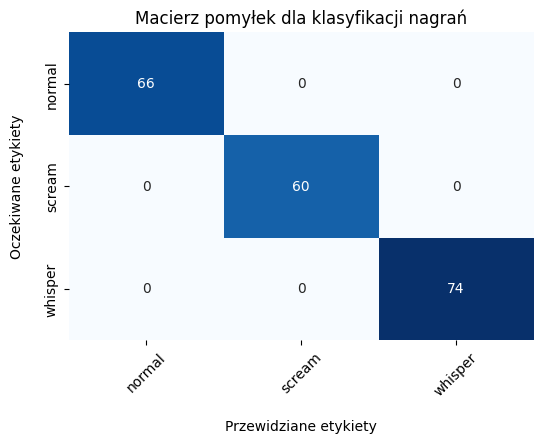

In [25]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

if not FINAL_EVALUATION_MODE:
    evaluate_algorithm(your_model.predict, val_ds)

### 6. Bonus - podejście alternatywne

Podczas gdy rozwiązanie modelowe traktowało audio jako obraz (spektrogram), niniejsza alternatywa zakłada, że sygnał dźwiękowy to sekwencja dyskretnych zdarzeń, co upodabnia go do danych tekstowych. Zamiast analizować rozkład energii w domenach częstotliwości, model uczy się bezpośrednio zależności czasowych w surowym sygnale.

**Kluczowa idea:** Zamiast generować spektrogramy i wykorzystywać warstwy konwolucyjne, tworzymy embeddingi z danych wejściowych i przetwarzamy je przez warstwę GRU. Proces obejmuje następujące kroki:

* **Downsampling i agregacja** - aby zredukować szum i skrócić długość sekwencji, sygnał jest dzielony na 20-próbkowe segmenty, które są uśredniane. Pozwala to na drastyczne zmniejszenie obciążenia obliczeniowego przy jednoczesnym zachowaniu ogólnego kształtu i zmian głośności sygnału.

* **Kwantyzacja i embeddingi** - ciągły sygnał amplitudowy zostaje zmapowany na 256 dyskretnych poziomów (indeksów). Warstwa `nn.Embedding` zamienia te indeksy na gęste wektory cech, co pozwala modelowi nauczyć się nieliniowych zależności między różnymi poziomami natężenia dźwięku.

* **Dwukierunkowa sieć GRU (Bidirectional Gated Recurrent Unit)** - GRU to rozwinięcie rekurencyjnej sieci neuronowej (RNN) wykorzystujące mechanizmy bramkowania (bramy aktualizacji i resetowania), które pozwalają modelowi selektywnie zapamiętywać istotne fragmenty sygnału i ignorować szum. Dzięki strukturze dwukierunkowej sieć analizuje kontekst dźwięku w obu kierunkach (przeszłość i przyszłość). Model nie operuje na „pikselach”, lecz analizuje ewolucję amplitudy w czasie, co może okazać się skuteczne przy wykrywaniu gwałtownych skoków energii (charakterystyczne dla krzyku) lub jednostajnego szumu (charakterystyczne dla szeptu).

Poniżej przedstawiono kod alternatywnego rozwiązania wraz z pełną pętlą uczenia oraz ewaluacją.

Training:   0%|          | 0/10 [00:00<?, ?it/s]

Training: 100%|██████████| 10/10 [00:21<00:00,  2.10s/it, train_loss=0.0877]


Ewaluacja modelu na zbiorze walidacyjnym:
Balanced accuracy na zbiorze walidacyjnym: 0.8873
Estymowana liczba punktów za zadanie: 74


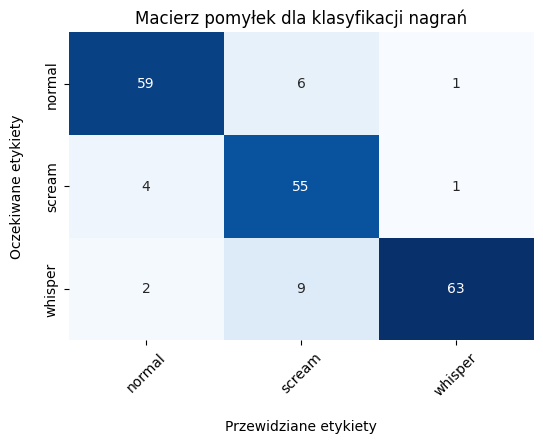

In [26]:
##### Kod alternatywnego rozwiązania - Embeddingi + GRU #####
class YourClassifierAlternative(nn.Module):
    """
    Klasyfikator audio oparty na kwantyzacji sygnału, embeddingach i sieci GRU.
    Traktuje sygnał audio jako sekwencję danych, podobnie jak w zadaniach NLP.
    """
    def __init__(self, max_len: int = 512, n_classes: int = 3):
        super(YourClassifierAlternative, self).__init__()
        self.max_len = max_len
        
        # 256 poziomów kwantyzacji + 1 dodatkowy indeks dla paddingu
        self.embedding = nn.Embedding(num_embeddings=257, embedding_dim=128, padding_idx=256)
        
        # Dwu kierunkowe GRU do ekstrakcji cech sekwencyjnych
        self.encoder = nn.GRU(
            input_size=128, 
            hidden_size=128, 
            batch_first=True, 
            bidirectional=True
        )
        
        # Warstwa wyjściowa - bierze pod uwagę oba kierunki GRU (128 * 2)
        self.linear = nn.Linear(in_features=256, out_features=n_classes)
    
    def preprocess(self, audio: torch.Tensor) -> torch.Tensor:
        """
        Przygotowuje surowy sygnał: downsampling, kwantyzacja i padding.
        
        Args:
            audio: Tensor o kształcie [Time] lub [Batch, Time]
        Returns:
            Zkwantyzowany tensor o stałej długości max_len.
        """
        if audio.dim() < 2:
            audio = audio.unsqueeze(0)

        # Downsampling: średnia z okien o rozmiarze 20
        num_chunks = audio.size(-1) // 20
        audio = audio[:, :(num_chunks * 20)].reshape(audio.size(0), -1, 20).mean(axis=-1)
        
        # Kwantyzacja do zakresu 0-255
        quantized = ((audio - (-1)) / (1 - (-1)) * 255).round().clamp(0, 255).type(torch.int)
        
        # Padding lub przycinanie do max_len
        if quantized.size(-1) < self.max_len:
            quantized = F.pad(quantized, (0, self.max_len - quantized.size(-1)), value=256)
        else:
            quantized = quantized[:, :self.max_len]
            
        return quantized

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass przez embeddingi i warstwy rekurencyjne.
        """
        x = self.embedding(x)
        
        # Ostatni stan ukryty (hidden state) dla obu kierunków
        _, h_n = self.encoder(x)
        
        # Konkatenacja ostatnich stanów z obu kierunków
        h = torch.cat([h_n[-2], h_n[-1]], dim=1)

        return self.linear(h) 
    
    @torch.no_grad()
    def predict(self, audio: torch.Tensor) -> list:
        """
        Wykonuje predykcję na surowym sygnale wejściowym.
        """
        self.eval()
        device = next(self.parameters()).device
        x = self.preprocess(audio.to(device))
        logits = self.forward(x)
        return torch.argmax(logits, dim=1).cpu().tolist()


##### Preprocessing danych w DataLoaderze dla alternatywnego modelu #####
def collate_fn_alternative(batch: list) -> dict:
    """Funkcja pomocnicza do przetwarzania batchy w DataLoaderze."""
    temp_model = YourClassifierAlternative() # Używamy logiki preprocessingu z klasy
    audios = [temp_model.preprocess(sample["audio"]) for sample in batch]
    labels = [sample["label"] for sample in batch]
    
    return {
        "audios": torch.cat(audios, dim=0), 
        "labels": torch.tensor(labels)
    }

train_dl = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=collate_fn_alternative)


##### Trening i ewaluacja alternatywnego modelu #####
your_model = YourClassifierAlternative().to(DEVICE)
optimizer = torch.optim.AdamW(your_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

epochs = 10

best_val = 0
best_state = None

pbar = tqdm(range(epochs), desc="Training", total=epochs)

for _ in pbar:
    epoch_losses = []
    your_model.train()

    for batch in train_dl:
        x = batch["audios"].to(DEVICE)
        y = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        output = your_model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.detach().cpu().item())
    
    avg_loss = np.mean(epoch_losses)

    pbar.set_postfix({"train_loss": avg_loss})

print("Ewaluacja modelu na zbiorze walidacyjnym:")
evaluate_algorithm(your_model.predict, val_ds)

Uzyskane wyniki potwierdzają, że w zadaniach klasyfikacji audio domena częstotliwościowa (spektrogramy) niesie znacznie silniejszy sygnał dyskryminacyjny niż surowa domena czasowa. Choć podejście sekwencyjne z wykorzystaniem embeddingów i sieci GRU oferuje niezłe wyniki, ustępuje ono skutecznością modelom konwolucyjnym opatych na spektrogramach. Wynika to z faktu, że traktowanie audio jako obrazu (2D) pozwala na efektywne wykorzystanie sprawdzonych mechanizmów ekstrakcji cech spektralnych, które w przypadku szeptu czy krzyku są znacznie bardziej wyraziste niż same fluktuacje amplitudy w czasie.

Niemniej jednak, niewątpliwym atutem alternatywnego rozwiązania jest jego mała złożoność obliczeniowa. Rozwiązanie sekwencyjne charakteryzuje się brakiem konieczności wyliczania kosztownych transformat, co w specyficznych warunkach systemów edge computing (np. prostych czujników IoT reagujących na krzyk) czyni uzyskany wynik potencjalnym kompromisem między precyzją a wydajnością.